# AMvalley03_s2900_200f-Slice — Selector-Vergleich (AMvalley03, frames 2900..3099)

Eigener Loader auf `output/AMvalley03_s2900_200f_results.csv`. Analog zum `s3100_200f`-Notebook,
aber für den 200-Frame-Slice ab Frame 2900.

**Sweep-Stand (2026-05-27):** 37 OK / 12 FAIL (alle `rc=137` = VRAM-Watchdog-Kill bei
~8 GiB GPU). Failed-Configs sind aggressive Selektoren mit hoher Map-Rate
(`coko_a005`, alle 4 `aim`-Varianten, `game_th030`, alle 3 `nurbs`-Varianten) und
die `skip_no_filter`-Pfade mit niedrigem `skip` (1/2/3) — alle laufen in den
gleichen ~9 GiB Peak-VRAM, weil ungezügeltes Mapping bei langem Slice die
Gaussian-Anzahl + Buffer/Storage-Manager überschreiten lässt.

Inhalt:
1. Fail-Analyse (Tabelle: was, warum, wann gekillt)
2. Bar-Charts: Variant × (Laufzeit, PSNR, Mapped-KFs)
3. Pareto: Laufzeit ↔ PSNR
4. Scatter: Laufzeit ↔ Mapped-KFs
5. Scatter: PSNR ↔ Mapped-KFs
6. Per-Frame-Konsens
7. Per-Selektor-Grid — welche Frames hat jeder Algorithmus gemappt?


> ## ⚠️ FAIRE VERSION
> Identischer Aufbau wie `analyze_sweep_AMvalley03_s2900_200f.ipynb`, aber **alle** `psnr`/`ssim`/`lpips` sind die **held-out Novel-View-Metriken** (`psnr_ho` …, feste Frame-Positionen), **nicht** train-view. Zusätzlich ATE. Gefiltert auf Runs mit fairer Eval. Methodik: `docs/FAIR_EVAL.md`.
>
> 47/56 Runs fair (9 VRAM-FAILs bei 400 Frames fehlen).

In [1]:
import re
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

# Wie scripts/log_sweep_row.py — finditer pro Zeile (tqdm-Escapes).
_KF_LINE_RX = re.compile(rb"\[\s*(\d+)\]\s+kf=([YNS])")


def parse_mapped_frames(log_path: Path) -> np.ndarray:
    """Frame-Indizes mit kf=Y (Selector-Accept → Mapper) aus run_*.log."""
    if not log_path.exists():
        return np.array([], dtype=np.int64)
    frames = []
    with open(log_path, "rb") as f:
        for raw in f:
            for m in _KF_LINE_RX.finditer(raw):
                if m.group(2) == b"Y":
                    frames.append(int(m.group(1)))
    return np.asarray(frames, dtype=np.int64)


In [2]:
REPO = Path('/home/philipp/Dokumente/Github/VINGS-Mono-BA')

CSV_S1000 = REPO / 'output' / 'AMvalley03_s2900_200f_results.csv'
df_raw = pd.read_csv(CSV_S1000)
df_raw = df_raw.sort_values('timestamp_start').drop_duplicates(['variant'], keep='last').reset_index(drop=True)

# === FAIRE VERSION: nur Runs mit fairer Eval; psnr/ssim/lpips := held-out ===
_n_before = len(df_raw)
df_raw = df_raw[df_raw['psnr_ho'].notna()].copy()
df_raw['psnr']=df_raw['psnr_ho']; df_raw['ssim']=df_raw['ssim_ho']; df_raw['lpips']=df_raw['lpips_ho']
print(f'FAIR: {len(df_raw)}/{_n_before} Runs mit fairer Eval (psnr=held-out psnr_ho)')

print(f'Total runs (latest per variant): {len(df_raw)}')
print('Status counts:')
print(df_raw['status'].value_counts())


FAIR: 57/58 Runs mit fairer Eval (psnr=held-out psnr_ho)
Total runs (latest per variant): 57
Status counts:
status
OK      56
FAIL     1
Name: count, dtype: int64


## 1) Fail-Analyse — alle 12 Failures sind VRAM-Kills

`rc=137` = SIGKILL durch den User-Watchdog (`feedback_vram_watchdog.md`) wenn ein Run
~8 GiB GPU überschreitet. Wir tabellieren Peak-VRAM, wo (Frame-Index) gekillt wurde
und wie viele KFs der Mapper bis dahin gefressen hat.


In [3]:
# (Fail-Analyse entfällt in der FAIREN Version: gefiltert auf Runs mit fairer
#  Eval -> alle status=OK, keine FAIL-Zeilen. VRAM-Crashes siehe normales
#  Notebook analyze_sweep_AMvalley03_s2900_200f.ipynb.)
print('Fail-Analyse entfällt in der fairen Version (nur Runs mit fairer Eval).')

Fail-Analyse entfällt in der fairen Version (nur Runs mit fairer Eval).


In [4]:
# (Fail-Analyse entfällt in der FAIREN Version: gefiltert auf Runs mit fairer
#  Eval -> alle status=OK, keine FAIL-Zeilen. VRAM-Crashes siehe normales
#  Notebook analyze_sweep_AMvalley03_s2900_200f.ipynb.)
print('Fail-Analyse entfällt in der fairen Version (nur Runs mit fairer Eval).')

Fail-Analyse entfällt in der fairen Version (nur Runs mit fairer Eval).


In [5]:
# Filter auf OK-Runs für die restlichen Plots.
df_s1000 = df_raw[df_raw['status'] == 'OK'].reset_index(drop=True)
print(f'OK runs: {len(df_s1000)}')
print(df_s1000.groupby('group').size())


OK runs: 56
group
adaptive_kf       4
aim               4
baseline          1
coko              4
game              3
mapskip           6
mm3dgs            4
nurbs             3
orbslam           4
skip_no_filter    6
two_gate          4
two_gate_v2       9
vista             4
dtype: int64


## 2) Bar-Charts pro Variant — Laufzeit, PSNR, Mapped-KFs

Sortiert pro Gruppe; Farbe = Gruppe. `vings_filter`-Baseline ist als Referenz mit dabei.


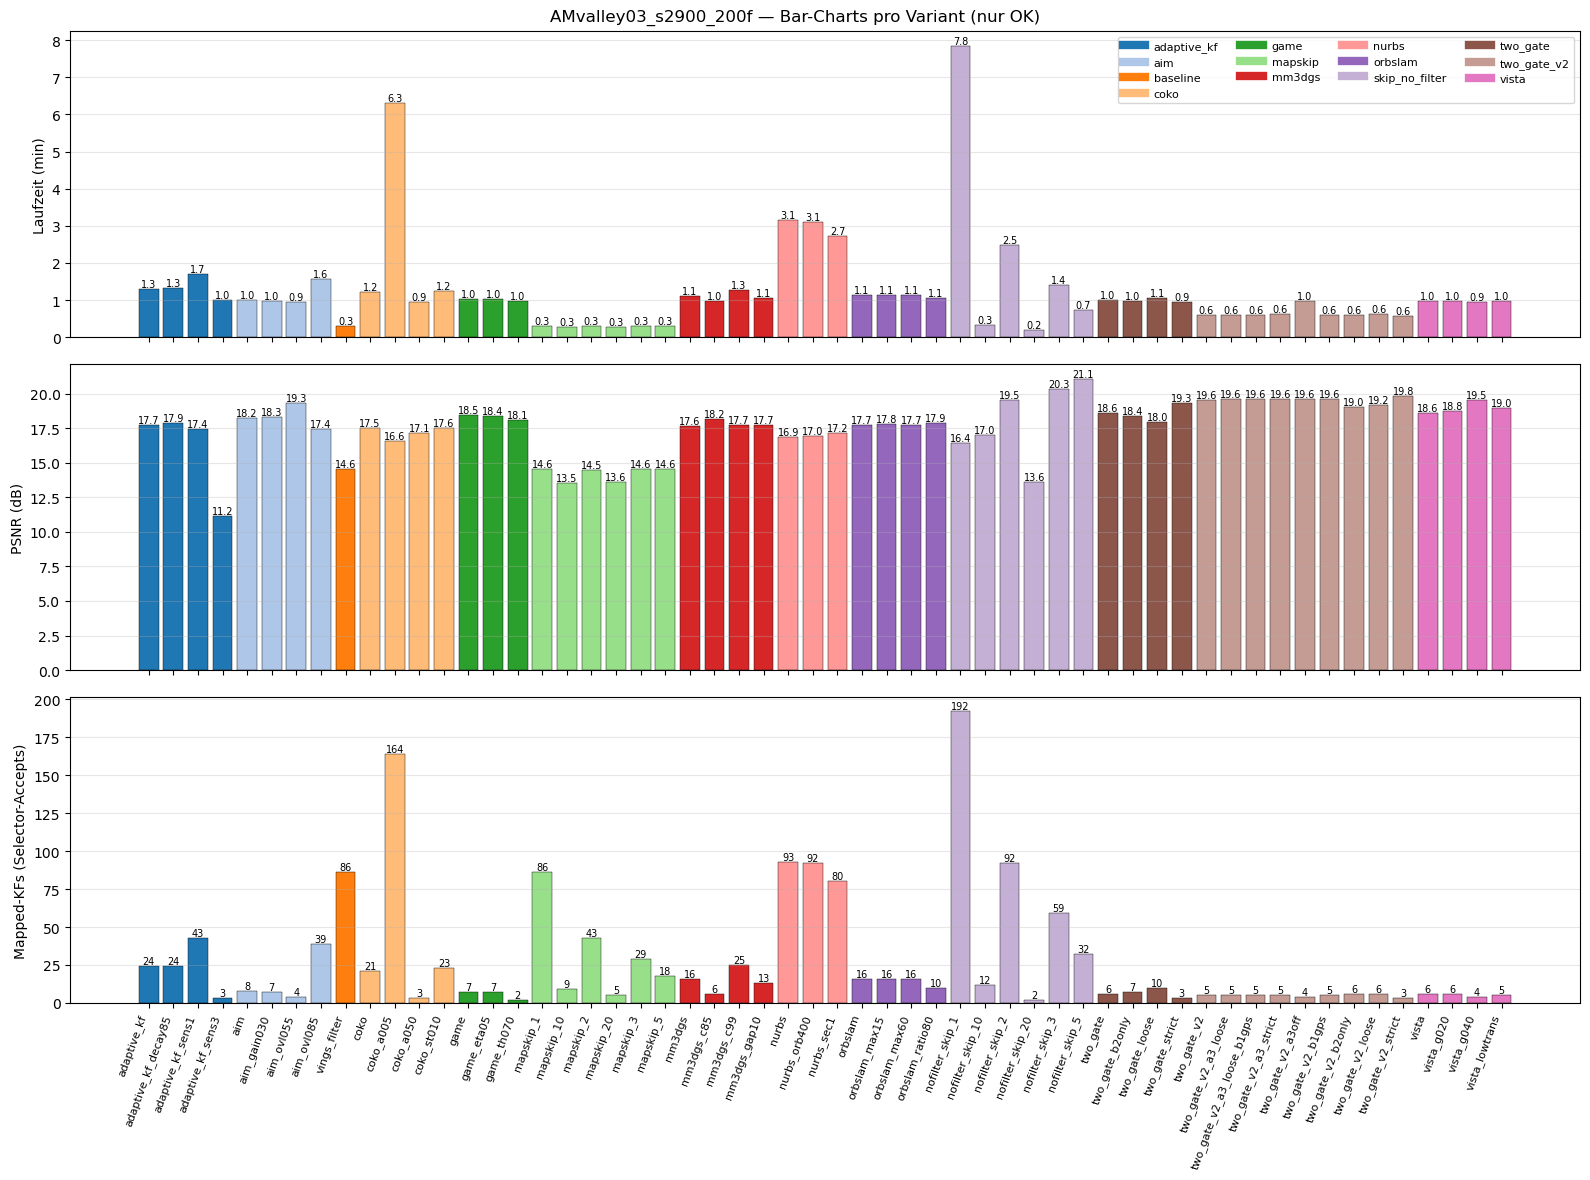

In [6]:
GROUPS = sorted(df_s1000['group'].unique())
GROUP_COLOR = dict(zip(GROUPS, plt.cm.tab20.colors[:len(GROUPS)]))

df_plot = df_s1000.sort_values(['group','variant']).reset_index(drop=True)
labels  = df_plot['variant'].tolist()
colors  = [GROUP_COLOR[g] for g in df_plot['group']]
x = np.arange(len(labels))

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
metrics = [
    ('duration_min', 'Laufzeit (min)', axes[0]),
    ('psnr',         'PSNR (dB)',       axes[1]),
    ('n_mapped',     'Mapped-KFs (Selector-Accepts)', axes[2]),
]
for col, ylabel, ax in metrics:
    ax.bar(x, df_plot[col], color=colors, edgecolor='black', linewidth=0.3)
    ax.set_ylabel(ylabel); ax.grid(alpha=0.3, axis='y')
    for xi, v in zip(x, df_plot[col]):
        ax.text(xi, v, f'{v:.1f}' if col != 'n_mapped' else f'{int(v)}', ha='center', va='bottom', fontsize=7)

axes[-1].set_xticks(x); axes[-1].set_xticklabels(labels, rotation=70, ha='right', fontsize=8)
legend_handles = [Line2D([0],[0], color=GROUP_COLOR[g], lw=6, label=g) for g in GROUPS]
axes[0].legend(handles=legend_handles, loc='upper right', ncol=4, fontsize=8)
fig.suptitle('AMvalley03_s2900_200f — Bar-Charts pro Variant (nur OK)', fontsize=12)
fig.tight_layout(); plt.show()


## 3) Pareto-Front — PSNR vs Laufzeit

Mapskip- und skip_no_filter-Gruppen werden vor dem Pareto-Vergleich entfernt
(unterschiedliche Spielregel: kein Selector-Algo).


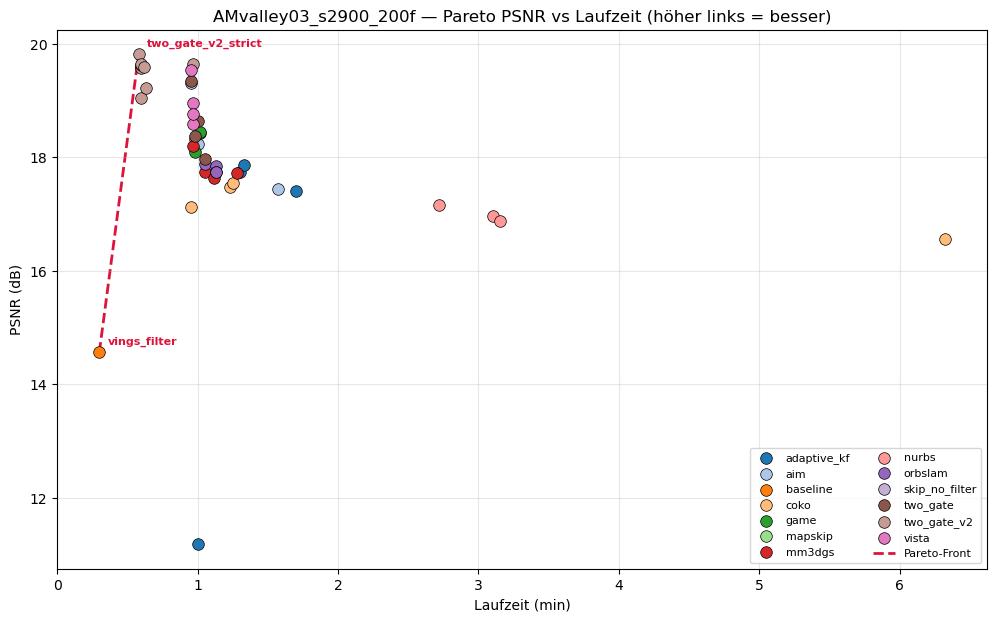

Pareto-Front (kürzeste Laufzeit → höchster PSNR):
      group            variant  duration_min    psnr  n_mapped  n_metric_frames
   baseline       vings_filter          0.30 14.5635        86                2
two_gate_v2 two_gate_v2_strict          0.58 19.8151         3                3


In [7]:
def pareto_front(df, x='duration_min', y='psnr'):
    s = df.sort_values(x).reset_index(drop=True)
    best = -np.inf; mask = []
    for v in s[y]:
        if v > best:
            mask.append(True); best = v
        else:
            mask.append(False)
    s['on_front'] = mask
    return s

df_s1000 = df_s1000[~df_s1000['group'].isin(['mapskip', 'skip_no_filter'])].copy()

pf = pareto_front(df_s1000, 'duration_min', 'psnr')
front = pf[pf['on_front']].sort_values('duration_min')

fig, ax = plt.subplots(figsize=(12, 7))
for g in GROUPS:
    sub = pf[pf['group']==g]
    ax.scatter(sub['duration_min'], sub['psnr'], s=70, color=GROUP_COLOR[g], label=g, edgecolor='black', linewidth=0.5, zorder=2)
ax.plot(front['duration_min'], front['psnr'], color='crimson', lw=2, ls='--', zorder=1, label='Pareto-Front')
for _, r in front.iterrows():
    ax.annotate(r['variant'], (r['duration_min'], r['psnr']),
                xytext=(6, 6), textcoords='offset points', fontsize=8, color='crimson', fontweight='bold')
ax.set_xlabel('Laufzeit (min)'); ax.set_ylabel('PSNR (dB)')
ax.set_title('AMvalley03_s2900_200f — Pareto PSNR vs Laufzeit (höher links = besser)')
ax.grid(alpha=0.3); ax.legend(loc='lower right', ncol=2, fontsize=8)
plt.show()

print('Pareto-Front (kürzeste Laufzeit → höchster PSNR):')
print(front[['group','variant','duration_min','psnr','n_mapped','n_metric_frames']].to_string(index=False))


## 4) Scatter — Laufzeit vs Mapped-KFs

Sanity-Check: lineare Beziehung erwartet (jeder Mapper-Run kostet ~0.7–1.0 s).
Outlier = Selektor mit hohem Overhead pro Frame (z. B. DINOv2 in `coko_slam`).


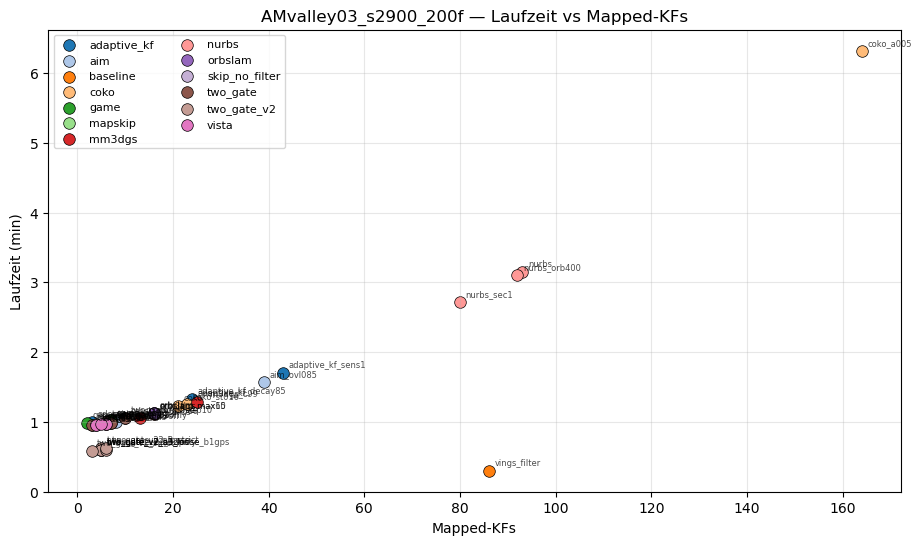

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))
for g in GROUPS:
    sub = df_s1000[df_s1000['group']==g]
    ax.scatter(sub['n_mapped'], sub['duration_min'], s=70, color=GROUP_COLOR[g], label=g, edgecolor='black', linewidth=0.5)
    for _, r in sub.iterrows():
        ax.annotate(r['variant'], (r['n_mapped'], r['duration_min']),
                    xytext=(4, 4), textcoords='offset points', fontsize=6, alpha=0.7)
ax.set_xlabel('Mapped-KFs'); ax.set_ylabel('Laufzeit (min)')
ax.set_title('AMvalley03_s2900_200f — Laufzeit vs Mapped-KFs')
ax.grid(alpha=0.3); ax.legend(loc='best', ncol=2, fontsize=8)
plt.show()


## 5) Scatter — PSNR vs Mapped-KFs

Sättigt PSNR ab einer KF-Anzahl?


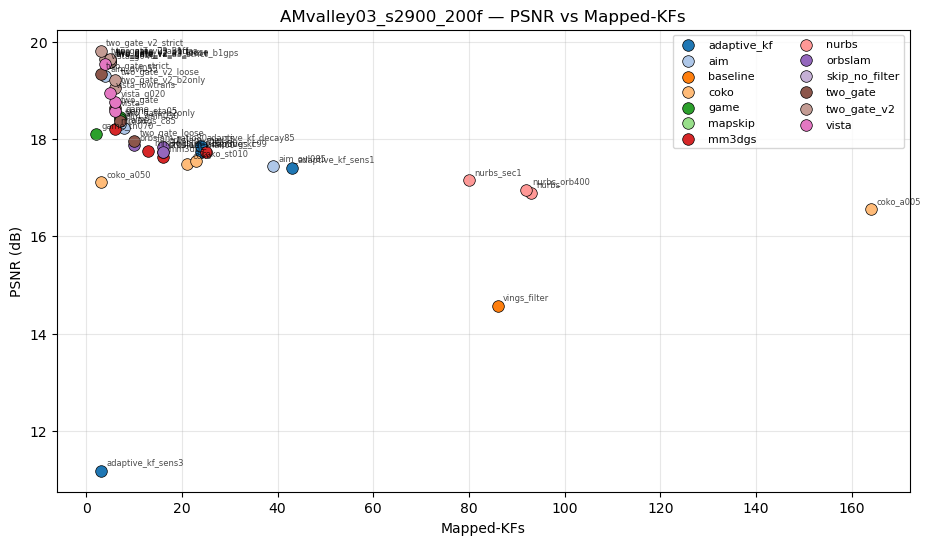

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))
for g in GROUPS:
    sub = df_s1000[df_s1000['group']==g]
    ax.scatter(sub['n_mapped'], sub['psnr'], s=70, color=GROUP_COLOR[g], label=g, edgecolor='black', linewidth=0.5)
    for _, r in sub.iterrows():
        ax.annotate(r['variant'], (r['n_mapped'], r['psnr']),
                    xytext=(4, 4), textcoords='offset points', fontsize=6, alpha=0.7)
ax.set_xlabel('Mapped-KFs'); ax.set_ylabel('PSNR (dB)')
ax.set_title('AMvalley03_s2900_200f — PSNR vs Mapped-KFs')
ax.grid(alpha=0.3); ax.legend(loc='best', ncol=2, fontsize=8)
plt.show()


## 6) Per-Frame-Konsens

Pro Frame-Index 0..199: wie viele Selektor-Variants haben `kf=Y` gesetzt.
Nur Selektoren (kein mapskip / skip_no_filter / baseline).


Selector runs: 44


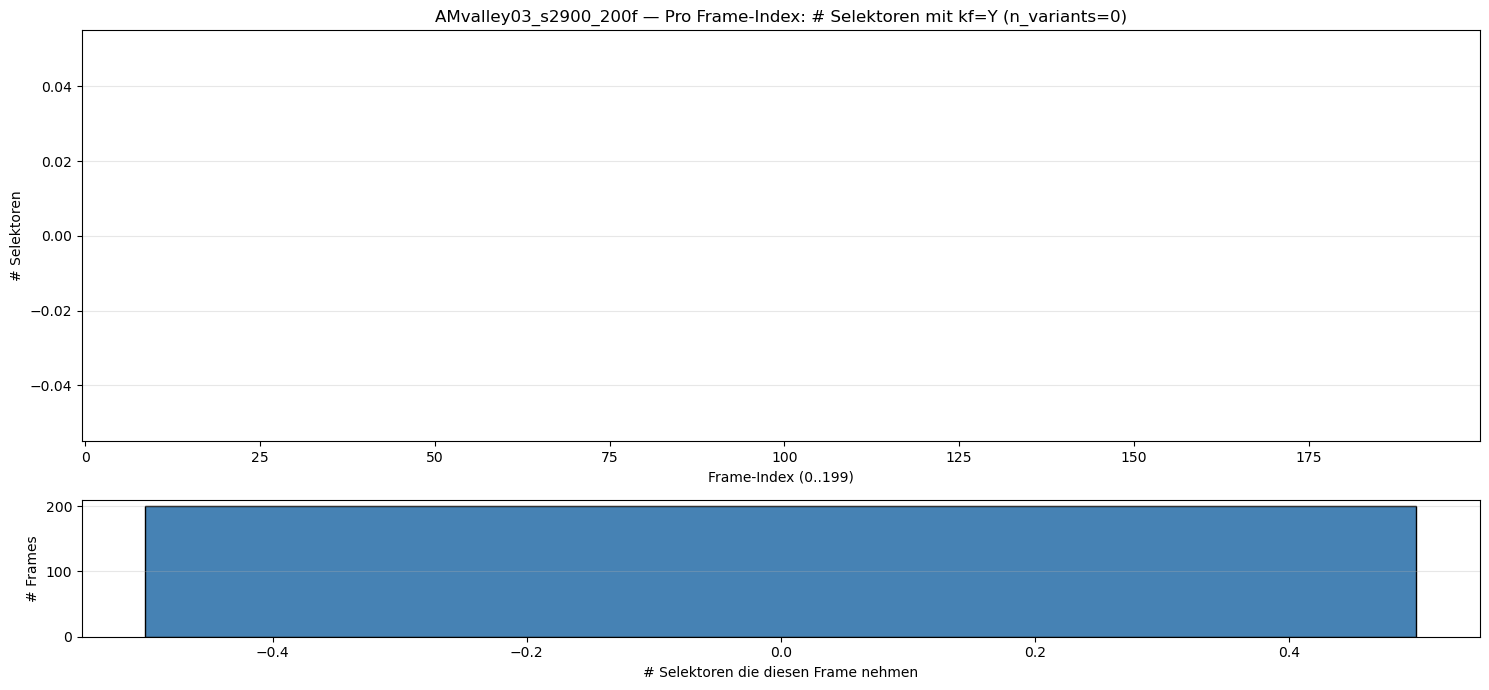

Top-10 Konsens-Frames:
  frame   0: 0 Selektoren
  frame   1: 0 Selektoren
  frame   2: 0 Selektoren
  frame   3: 0 Selektoren
  frame   4: 0 Selektoren
  frame   5: 0 Selektoren
  frame   6: 0 Selektoren
  frame   7: 0 Selektoren
  frame   8: 0 Selektoren
  frame   9: 0 Selektoren


In [10]:
SELECTOR_ONLY = df_s1000[~df_s1000['group'].isin(['mapskip','skip_no_filter'])].copy()
print(f'Selector runs: {len(SELECTOR_ONLY)}')

frames_by_variant = {}
for _, r in SELECTOR_ONLY.iterrows():
    if pd.isna(r['log_path']):
        continue
    arr = parse_mapped_frames(Path(r['log_path']))
    if len(arr) == 0:
        continue
    frames_by_variant[r['variant']] = np.unique(arr)

N = 200
consensus = np.zeros(N, dtype=np.int32)
for v, frames in frames_by_variant.items():
    valid = frames[frames < N]
    consensus[valid] += 1

fig, axes = plt.subplots(2, 1, figsize=(15, 7), gridspec_kw={'height_ratios':[3,1]})
axes[0].bar(np.arange(N), consensus, width=1.0, color='steelblue', edgecolor='none')
axes[0].set_title(f'AMvalley03_s2900_200f — Pro Frame-Index: # Selektoren mit kf=Y (n_variants={len(frames_by_variant)})')
axes[0].set_xlabel('Frame-Index (0..199)'); axes[0].set_ylabel('# Selektoren')
axes[0].set_xlim(-0.5, N-0.5); axes[0].grid(alpha=0.3, axis='y')

bins = np.arange(0, len(frames_by_variant)+2) - 0.5
axes[1].hist(consensus, bins=bins, color='steelblue', edgecolor='black')
axes[1].set_xlabel('# Selektoren die diesen Frame nehmen'); axes[1].set_ylabel('# Frames')
axes[1].grid(alpha=0.3, axis='y')
fig.tight_layout(); plt.show()

# Tabelle: Top-Consensus-Frames
top = np.argsort(-consensus)[:10]
print('Top-10 Konsens-Frames:')
for idx in top:
    print(f'  frame {idx:3d}: {consensus[idx]} Selektoren')


## 6) Per-Selektor-Grid — welche Frames hat jeder Algorithmus gemappt?

Ein kleines Subplot pro Selektor-Variant. X-Achse = Frame-Index (0..199),
Y-Achse = 1 wenn der Selektor diesen Frame an den Mapper gegeben hat (`kf=Y`), sonst 0.
Hilft zu sehen *wo* in der Sequenz ein Algorithmus dicht/sparsam selektiert.


Variants in grid: 0


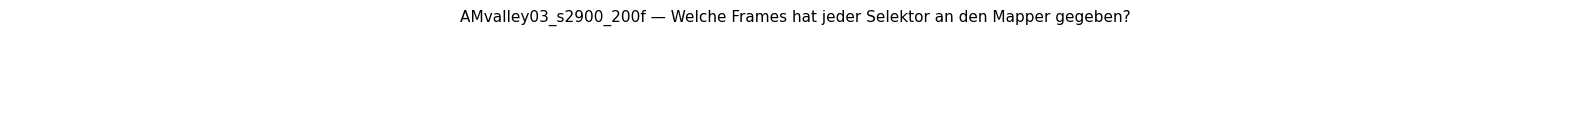

In [11]:
import math

# Re-use frames_by_variant_s from previous cell (s3100) / frames_by_variant from s1000 nb.
fbv = frames_by_variant
N   = 200

# Sort variants by group then name for nicer layout.
df_sel = df_s1000[~df_s1000['group'].isin(['mapskip','skip_no_filter'])]
ordered = (df_sel.sort_values(['group','variant'])['variant'].tolist())
variants = [v for v in ordered if v in fbv]
print(f'Variants in grid: {len(variants)}')

ncols = 4
nrows = max(1, math.ceil(len(variants) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4.0, nrows*1.3), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

var_to_group = dict(zip(df_s1000['variant'], df_s1000['group']))

for ax, v in zip(axes, variants):
    frames = fbv[v]
    mask = np.zeros(N, dtype=np.int8)
    valid = frames[frames < N]
    mask[valid] = 1
    g = var_to_group.get(v, 'sel')
    col = GROUP_COLOR.get(g, 'steelblue')
    ax.bar(np.arange(N), mask, width=1.0, color=col, edgecolor='none')
    ax.set_title(f'{v}  (n={int(mask.sum())})', fontsize=8)
    ax.set_ylim(0, 1.05); ax.set_yticks([])
    ax.set_xlim(-0.5, N-0.5)
    ax.tick_params(axis='x', labelsize=7)
    ax.grid(False)

# Hide unused subplots
for ax in axes[len(variants):]:
    ax.axis('off')

for ax in axes[-ncols:]:
    ax.set_xlabel('Frame-Index', fontsize=7)

fig.suptitle('AMvalley03_s2900_200f — Welche Frames hat jeder Selektor an den Mapper gegeben?', fontsize=11)
fig.tight_layout()
plt.show()


## two_gate / two_gate_v2 — Reject-Grund pro Frame

Für jede `two_gate`/`two_gate_v2`-Variante: an welchem Pipeline-Schritt wurde
jeder Tracker-KF-Frame **akzeptiert** oder **aussortiert**. Quelle sind die
`fs(step=...)`-Tokens in den Run-Logs (`verbose: true` im Selector).

Schritt-Bedeutung: `motion+novelty`=akzeptiert auf eigene Stärke ·
`force_after`=Failsafe-Accept · `first`=Bootstrap · `B1_pose_below_min*`=keine
Bewegung · `B1_gps_below_min`=GPS-Weg zu klein (nur v1) · `B1_ssim_veto`=Bild
quasi identisch · `B2B3_novelty_below_theta`=zu wenig neue Szene ·
`spacing_blocked`/`rate_capped`=Budget-Cap.


In [12]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---- self-contained CSV resolver --------------------------------------------
def _find_csv(name):
    cands = [Path(name), Path("../output") / name, Path("output") / name,
             Path.home() / "Dokumente/Github/VINGS-Mono-BA/output" / name]
    for c in cands:
        if c.exists():
            return c
    return cands[1]

CSV_FAIR = _find_csv("AMvalley03_s2900_200f_results.csv")
N_FRAMES = 200

_df = (pd.read_csv(CSV_FAIR)
         .sort_values("timestamp_end")
         .drop_duplicates("variant", keep="last"))

# === FAIRE VERSION: nur Runs mit fairer Eval; psnr/ssim/lpips := held-out ===
_n_before = len(df_raw)
df_raw = df_raw[df_raw['psnr_ho'].notna()].copy()
df_raw['psnr']=df_raw['psnr_ho']; df_raw['ssim']=df_raw['ssim_ho']; df_raw['lpips']=df_raw['lpips_ho']
print(f'FAIR: {len(df_raw)}/{_n_before} Runs mit fairer Eval (psnr=held-out psnr_ho)')

_tg = _df[_df["group"].isin(["two_gate", "two_gate_v2"])]

STEP_COLOR = {
    "first":                          "#000000",
    "motion+novelty":                 "#2ca02c",
    "force_after":                    "#bcbd22",
    "B1_pose_below_min":              "#ff7f0e",
    "B1_pose_below_min(no_gps)":      "#ff7f0e",
    "B1_pose_below_min(noise_floor)": "#ffbb78",
    "B1_gps_below_min":               "#e6ab02",
    "B1_ssim_veto":                   "#d62728",
    "B2B3_novelty_below_theta":       "#1f77b4",
    "spacing_blocked":                "#9467bd",
    "rate_capped":                    "#8c564b",
}

_line_re = re.compile(r"\[\s*(\d+)\]\s+kf=([YNS])")
_step_re = re.compile(r"fs\(step=([^)]+)\)")

def parse_steps(log_path):
    """(frame_idx, kf_flag, step) for frames where the selector actually ran."""
    out = []
    try:
        with open(log_path, "rb") as f:
            for raw in f:
                ln = raw.decode("utf-8", "ignore")
                m = _line_re.search(ln)
                if not m:
                    continue
                sm = _step_re.search(ln)
                if sm is None:
                    continue            # kf=N -> selector not called
                out.append((int(m.group(1)), m.group(2), sm.group(1)))
    except Exception as e:
        print("parse fail", log_path, e)
    return out

rows = [(r.variant, parse_steps(r.log_path))
        for _, r in _tg.iterrows() if isinstance(r.log_path, str)]
rows = [(v, s) for v, s in rows if s]

if not rows:
    print("Keine two_gate-Logs mit fs(step=...) gefunden. "
          "Sweep mit den aktualisierten Configs (verbose:true) neu laufen lassen.")
else:
    # (1) per-frame decision strip ------------------------------------------
    fig, ax = plt.subplots(figsize=(14, 0.55 * len(rows) + 1.8))
    seen = set()
    for y, (v, steps) in enumerate(rows):
        for fidx, kf, step in steps:
            ax.scatter(fidx, y, c=STEP_COLOR.get(step, "#cccccc"),
                       s=42, marker="s")
            seen.add(step)
    ax.set_yticks(range(len(rows)))
    ax.set_yticklabels([v for v, _ in rows])
    ax.set_xlim(-1, N_FRAMES)
    ax.set_xlabel("frame index")
    ax.set_title("two_gate-Entscheidung pro Tracker-KF (Farbe = Pipeline-Schritt)")
    handles = [Line2D([0], [0], marker="s", color="w",
                      markerfacecolor=STEP_COLOR[s], markersize=10, label=s)
               for s in STEP_COLOR if s in seen]
    ax.legend(handles=handles, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
    plt.tight_layout(); plt.show()

    # (2) stacked reason counts per variant ---------------------------------
    used = [s for s in STEP_COLOR
            if any(s == x[2] for _, steps in rows for x in steps)]
    counts = {v: {s: 0 for s in used} for v, _ in rows}
    for v, steps in rows:
        for _, _, s in steps:
            counts[v][s] += 1
    fig, ax = plt.subplots(figsize=(11, 5))
    bottom = np.zeros(len(rows))
    labels = [v for v, _ in rows]
    for s in used:
        vals = np.array([counts[v][s] for v in labels])
        ax.bar(labels, vals, bottom=bottom, color=STEP_COLOR[s], label=s)
        bottom += vals
    ax.set_ylabel("Tracker-KF-Frames")
    ax.set_title("two_gate: warum jeder Tracker-KF akzeptiert / verworfen wurde")
    ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()


FAIR: 57/57 Runs mit fairer Eval (psnr=held-out psnr_ho)
parse fail /home/philipp/Dokumente/Github/VINGS-Mono-BA/output/exp_AMvalley03_s2900_200f/06-19-23-02-generic_vo-AMvalley03_s2900_200f_two_gate-/run_20260619_170241.log [Errno 2] No such file or directory: '/home/philipp/Dokumente/Github/VINGS-Mono-BA/output/exp_AMvalley03_s2900_200f/06-19-23-02-generic_vo-AMvalley03_s2900_200f_two_gate-/run_20260619_170241.log'
parse fail /home/philipp/Dokumente/Github/VINGS-Mono-BA/output/exp_AMvalley03_s2900_200f/06-19-23-04-generic_vo-AMvalley03_s2900_200f_two_gate_b2only-/run_20260619_170358.log [Errno 2] No such file or directory: '/home/philipp/Dokumente/Github/VINGS-Mono-BA/output/exp_AMvalley03_s2900_200f/06-19-23-04-generic_vo-AMvalley03_s2900_200f_two_gate_b2only-/run_20260619_170358.log'
parse fail /home/philipp/Dokumente/Github/VINGS-Mono-BA/output/exp_AMvalley03_s2900_200f/06-19-23-05-generic_vo-AMvalley03_s2900_200f_two_gate_loose-/run_20260619_170513.log [Errno 2] No such file or d

## Faire, selektionsunabhängige Metriken: ATE + Held-out-Novel-View-PSNR

Der `psnr`/`ssim`/`lpips` oben ist **train-view & selektionsabhängig** (nur auf
den Frames, die der Selektor zufällig gemappt hat → nicht vergleichbar).

Hier die fairen Werte aus `fair_metrics.json` (gleiches, fixes Eval-Set für
**alle** Configs):
* **`ate_rmse_m`** — Sim(3)-alignierter Trajektorien-Fehler vs. GT (DJI).
  Misst Tracking-Qualität, unabhängig von der KF-Zahl. Kleiner = besser.
* **`psnr_ho`/`ssim_ho`/`lpips_ho`** — Novel-View aus der finalen Map an jeder
  10. Frame-Position (eigene, interpolierte Pose, gegen GT-Bild). Misst
  Mapping-Qualität auf gemeinsamem Maßstab. Größer (PSNR/SSIM) = besser.


FAIR: 57/57 Runs mit fairer Eval (psnr=held-out psnr_ho)


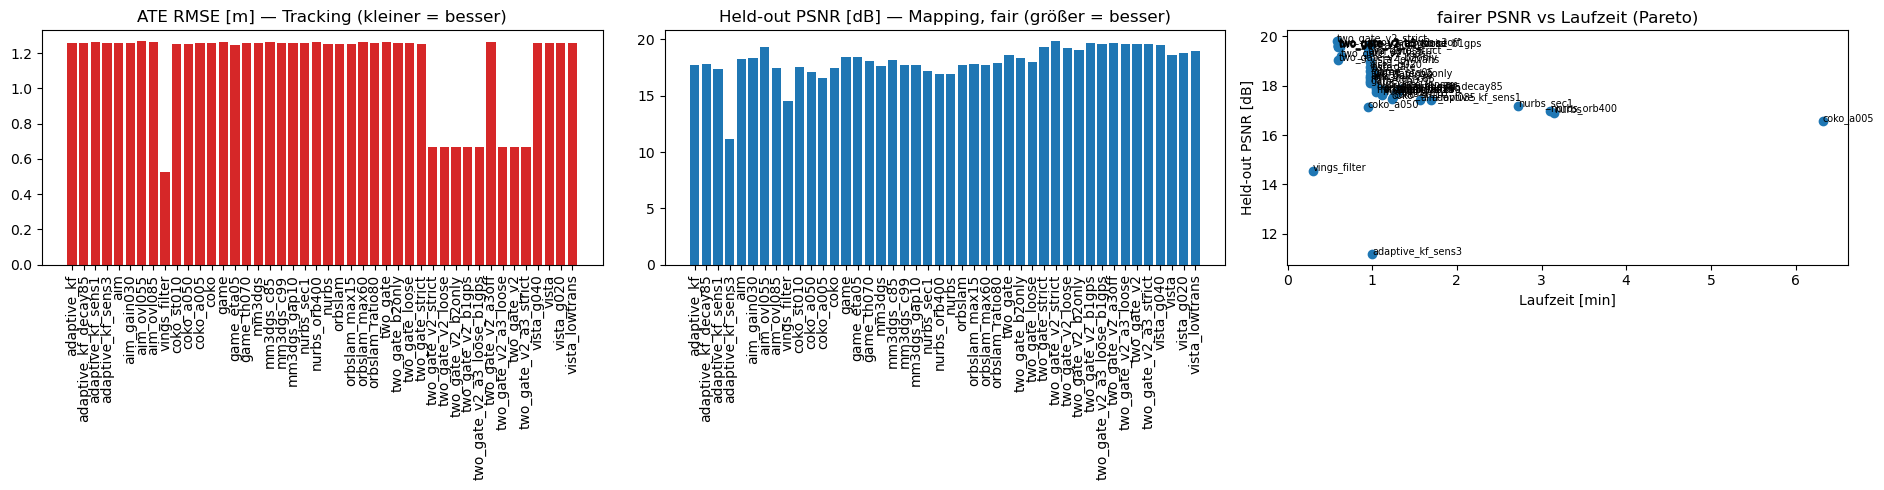

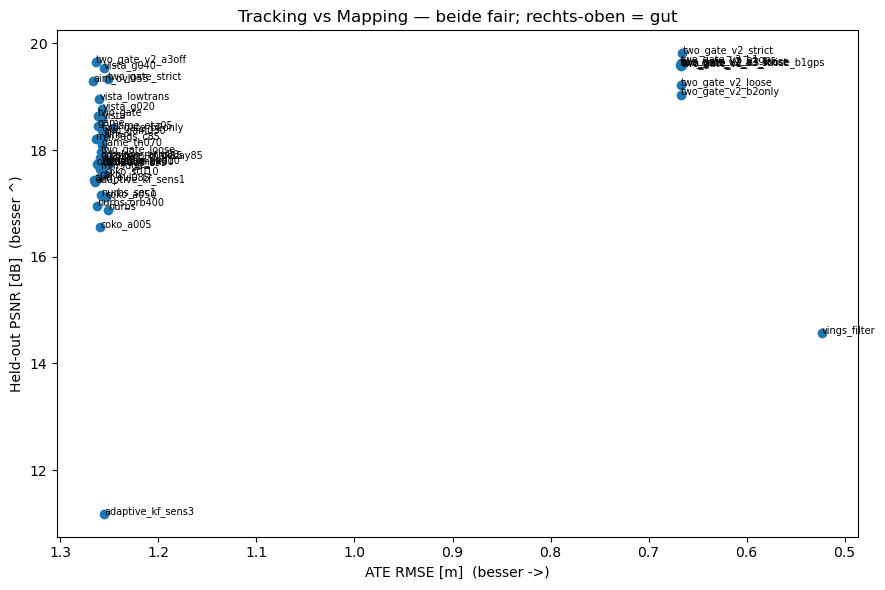

In [13]:
_dff = (pd.read_csv(CSV_FAIR)
          .sort_values("timestamp_end")
          .drop_duplicates("variant", keep="last"))

# === FAIRE VERSION: nur Runs mit fairer Eval; psnr/ssim/lpips := held-out ===
_n_before = len(df_raw)
df_raw = df_raw[df_raw['psnr_ho'].notna()].copy()
df_raw['psnr']=df_raw['psnr_ho']; df_raw['ssim']=df_raw['ssim_ho']; df_raw['lpips']=df_raw['lpips_ho']
print(f'FAIR: {len(df_raw)}/{_n_before} Runs mit fairer Eval (psnr=held-out psnr_ho)')

_dff = _dff[_dff["status"] == "OK"]
fairm = _dff.dropna(subset=["psnr_ho"]) if "psnr_ho" in _dff.columns else _dff.iloc[0:0]

if fairm.empty:
    print("Noch keine fairen Metriken in der CSV. Sweep neu laufen lassen "
          "(fair_eval schreibt fair_metrics.json -> Spalten ate_rmse_m/psnr_ho).")
else:
    sel = fairm[~fairm["group"].isin(["mapskip", "skip_no_filter"])].sort_values("group")

    fig, axes = plt.subplots(1, 3, figsize=(19, 5))
    axes[0].bar(sel["variant"], sel["ate_rmse_m"], color="#d62728")
    axes[0].set_title("ATE RMSE [m] — Tracking (kleiner = besser)")
    axes[1].bar(sel["variant"], sel["psnr_ho"], color="#1f77b4")
    axes[1].set_title("Held-out PSNR [dB] — Mapping, fair (größer = besser)")
    axes[2].scatter(sel["duration_min"], sel["psnr_ho"])
    for _, r in sel.iterrows():
        axes[2].annotate(r["variant"], (r["duration_min"], r["psnr_ho"]), fontsize=7)
    axes[2].set_xlabel("Laufzeit [min]"); axes[2].set_ylabel("Held-out PSNR [dB]")
    axes[2].set_title("fairer PSNR vs Laufzeit (Pareto)")
    for a in axes[:2]:
        a.tick_params(axis="x", rotation=90)
    plt.tight_layout(); plt.show()

    # quality-quality: Tracking vs Mapping, beide fair
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(sel["ate_rmse_m"], sel["psnr_ho"])
    for _, r in sel.iterrows():
        ax.annotate(r["variant"], (r["ate_rmse_m"], r["psnr_ho"]), fontsize=7)
    ax.set_xlabel("ATE RMSE [m]  (besser ->)"); ax.invert_xaxis()
    ax.set_ylabel("Held-out PSNR [dB]  (besser ^)")
    ax.set_title("Tracking vs Mapping — beide fair; rechts-oben = gut")
    plt.tight_layout(); plt.show()
